In [9]:
import pandas as pd
ratings=pd.read_csv(
    "u.data",
    sep="\t",
    names=["user_id", "movie_id", "rating", "timestamp"]
)
df.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [10]:
movies=pd.read_csv(
    "u.item",
    sep="|",
    encoding="latin-1",
    header=None,
    usecols=[0,1],
    names=["movie_id", "title"]
)
movies.head()

,movie_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


In [11]:
import numpy as np

In [13]:
df=pd.merge(ratings, movies, on="movie_id")
df.head()

,user_id,movie_id,rating,timestamp,title
0,196,242,3,881250949,Kolya (1996)
1,186,302,3,891717742,L.A. Confidential (1997)
2,22,377,1,878887116,Heavyweights (1994)
3,244,51,2,880606923,Legends of the Fall (1994)
4,166,346,1,886397596,Jackie Brown (1997)


In [14]:
user_item_matrix=df.pivot_table(
    index="user_id",
    columns="title",
    values="rating"
)

In [15]:
user_item_filled=user_item_matrix.fillna(0)

In [16]:
from sklearn.metrics.pairwise import cosine_similarity
user_similarity=cosine_similarity(user_item_filled)
user_similarity_df=pd.DataFrame(
    user_similarity,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)

In [18]:
def recommend_movies(user_id, num_recommendations=5):
    # Get similar users
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:6]
    
    # Get their ratings
    similar_users_ratings = user_item_matrix.loc[similar_users.index]
    
    # Average ratings
    recommendations = similar_users_ratings.mean().sort_values(ascending=False)
    
    return recommendations.head(num_recommendations)

In [19]:
recommend_movies(1)

title
Secrets & Lies (1996)         5.0
Alien: Resurrection (1997)    5.0
Angels and Insects (1995)     5.0
Hamlet (1996)                 5.0
Babe (1995)                   5.0
dtype: float64

In [23]:
item_similarity = cosine_similarity(user_item_filled.T)

item_similarity_df = pd.DataFrame(
item_similarity,
index=user_item_matrix.columns,
columns=user_item_matrix.columns
)



In [24]:
def recommend_similar_movies(movie_name, n=5):
    similar_movies = item_similarity_df[movie_name].sort_values(ascending=False)[1:n+1]
    return similar_movies


In [25]:
recommend_similar_movies("Star Wars (1977)")

title
Return of the Jedi (1983)          0.884476
Raiders of the Lost Ark (1981)     0.764885
Empire Strikes Back, The (1980)    0.749819
Toy Story (1995)                   0.734572
Godfather, The (1972)              0.697332
Name: Star Wars (1977), dtype: float64

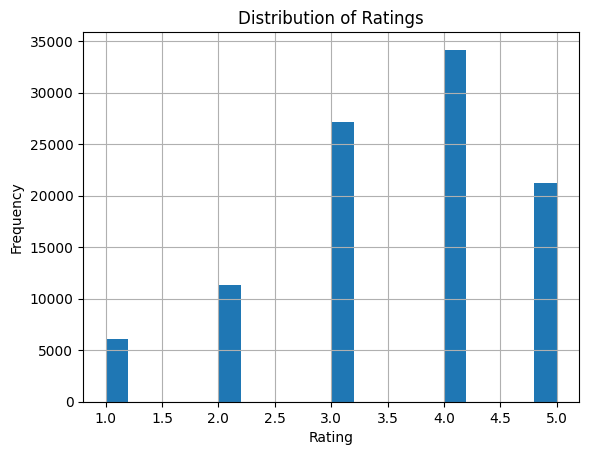

In [26]:
import matplotlib.pyplot as plt
df['rating'].hist(bins=20)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

# 🎬 Movie Recommendation System

## 📌 Objective
The goal of this project is to build a personalized movie recommendation system using collaborative filtering techniques.

---

## Dataset
- MovieLens 100K dataset
- 100,000 ratings from 943 users on 1682 movies

---

## Approach

### 1. Data Preprocessing
- Loaded user ratings and movie data
- Merged datasets using movie_id
- Created user-item matrix

### 2. Collaborative Filtering
- Used cosine similarity to find similar users/movies
- Built recommendation functions:
- Recommend movies to users
- Recommend similar movies

---

## Model Logic

- If two users rate movies similarly → they are similar
- If two movies are rated by similar users → they are similar

---

## Results

### ✔ Movie Recommendations
- System successfully recommends top-rated movies for users

### ✔ Similar Movie Detection
Example:
- Input: *Star Wars (1977)*
- Output:
- Return of the Jedi (1983)
- Empire Strikes Back (1980)
- Raiders of the Lost Ark (1981)

---

## 📊 Visualization
- Distribution of ratings shows most users rate between 3–5

---

## Conclusion
This project demonstrates how machine learning can be used to build real-world recommendation systems like Netflix or Amazon.

---

## Tech Stack
- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib

---

## 📌 Future Improvements
- Use Matrix Factorization (SVD)
- Build web app using Streamlit
- Add user login systemFuture Improvements
